In [74]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

In [75]:
# %pip install numpy scipy scikit-learn

In [76]:
from scipy.io import arff

# 1. Load the ARFF file using SciPy
data, meta = arff.loadarff("C:/Users/USUARIO/OneDrive/Documents/Maestria/Data mining/Proyecto del curso/Data/V2/V3/data.arff")

# 2. Convert it into a Pandas DataFrame
df = pd.DataFrame(data)

df.head()

,customer_state,total_payment_value,total_freight,total_weight_g,total_volume_cm3,principal_category_by_price,principal_seller_state_by_price,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,...,dias_entrega_promedio_7d_avg,dias_entrega_promedio_t2,dias_entrega_promedio_prev_month,es_post_domingo_festivo,es_diciembre,es_fin_de_semana_extendido,distancia_km,distancia_total_t1,distancia_total_prev_month,delivery_days
0,b'SP',38.71,8.72,500.0,1976.0,b'utilidades_domesticas',b'SP',2017.0,111.890769,91.660,...,10.860524,10.043478,11.886244,1.0,0.0,0.0,18.576110,4025.883311,291113.407386,8.0
1,b'SP',32.70,12.80,200.0,2560.0,b'cama_mesa_banho',b'SP',2018.0,169.101283,112.680,...,7.619223,9.063401,11.552505,0.0,0.0,0.0,309.131371,25226.900324,488209.852444,4.0
2,b'SP',54.36,16.11,583.0,8400.0,b'brinquedos',b'SP',2018.0,146.652034,100.230,...,14.771980,15.841772,14.586934,0.0,0.0,0.0,430.144201,21694.682189,421109.470293,11.0
3,b'SP',29.75,11.85,250.0,4800.0,b'cama_mesa_banho',b'SP',2017.0,170.919272,117.600,...,12.902686,12.000000,11.846389,0.0,0.0,0.0,209.757656,9623.066166,343516.704227,6.0
4,b'SP',118.86,8.96,525.0,4368.0,b'beleza_saude',b'SP',2017.0,219.488889,106.805,...,11.561738,10.369565,11.021440,1.0,0.0,0.0,11.680956,6110.978959,304388.330097,21.0


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25516 entries, 0 to 25515
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   customer_state                    25516 non-null  object 
 1   total_payment_value               25516 non-null  float64
 2   total_freight                     25516 non-null  float64
 3   total_weight_g                    25516 non-null  float64
 4   total_volume_cm3                  25516 non-null  float64
 5   principal_category_by_price       25516 non-null  object 
 6   principal_seller_state_by_price   25516 non-null  object 
 7   purchase_year                     25516 non-null  float64
 8   facturacion_promedio_t1           25516 non-null  float64
 9   facturacion_mediana_t1            25516 non-null  float64
 10  facturacion_std_t1                25516 non-null  float64
 11  facturacion_total_7d_avg          25516 non-null  float64
 12  dias

In [78]:
#Correccion de tipos de datos
df['customer_state']=df['customer_state'].astype('category')
df["principal_category_by_price"] = df["principal_category_by_price"].astype('category')
df["principal_seller_state_by_price"] = df["principal_seller_state_by_price"].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25516 entries, 0 to 25515
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   customer_state                    25516 non-null  category
 1   total_payment_value               25516 non-null  float64 
 2   total_freight                     25516 non-null  float64 
 3   total_weight_g                    25516 non-null  float64 
 4   total_volume_cm3                  25516 non-null  float64 
 5   principal_category_by_price       25516 non-null  category
 6   principal_seller_state_by_price   25516 non-null  category
 7   purchase_year                     25516 non-null  float64 
 8   facturacion_promedio_t1           25516 non-null  float64 
 9   facturacion_mediana_t1            25516 non-null  float64 
 10  facturacion_std_t1                25516 non-null  float64 
 11  facturacion_total_7d_avg          25516 non-null  floa

array([[<Axes: title={'center': 'total_payment_value'}>,
        <Axes: title={'center': 'total_freight'}>,
        <Axes: title={'center': 'total_weight_g'}>,
        <Axes: title={'center': 'total_volume_cm3'}>],
       [<Axes: title={'center': 'purchase_year'}>,
        <Axes: title={'center': 'facturacion_promedio_t1'}>,
        <Axes: title={'center': 'facturacion_mediana_t1'}>,
        <Axes: title={'center': 'facturacion_std_t1'}>],
       [<Axes: title={'center': 'facturacion_total_7d_avg'}>,
        <Axes: title={'center': 'dias_entrega_promedio_7d_avg'}>,
        <Axes: title={'center': 'dias_entrega_promedio_t2'}>,
        <Axes: title={'center': 'dias_entrega_promedio_prev_month'}>],
       [<Axes: title={'center': 'es_post_domingo_festivo'}>,
        <Axes: title={'center': 'es_diciembre'}>,
        <Axes: title={'center': 'es_fin_de_semana_extendido'}>,
        <Axes: title={'center': 'distancia_km'}>],
       [<Axes: title={'center': 'distancia_total_t1'}>,
        <Axes

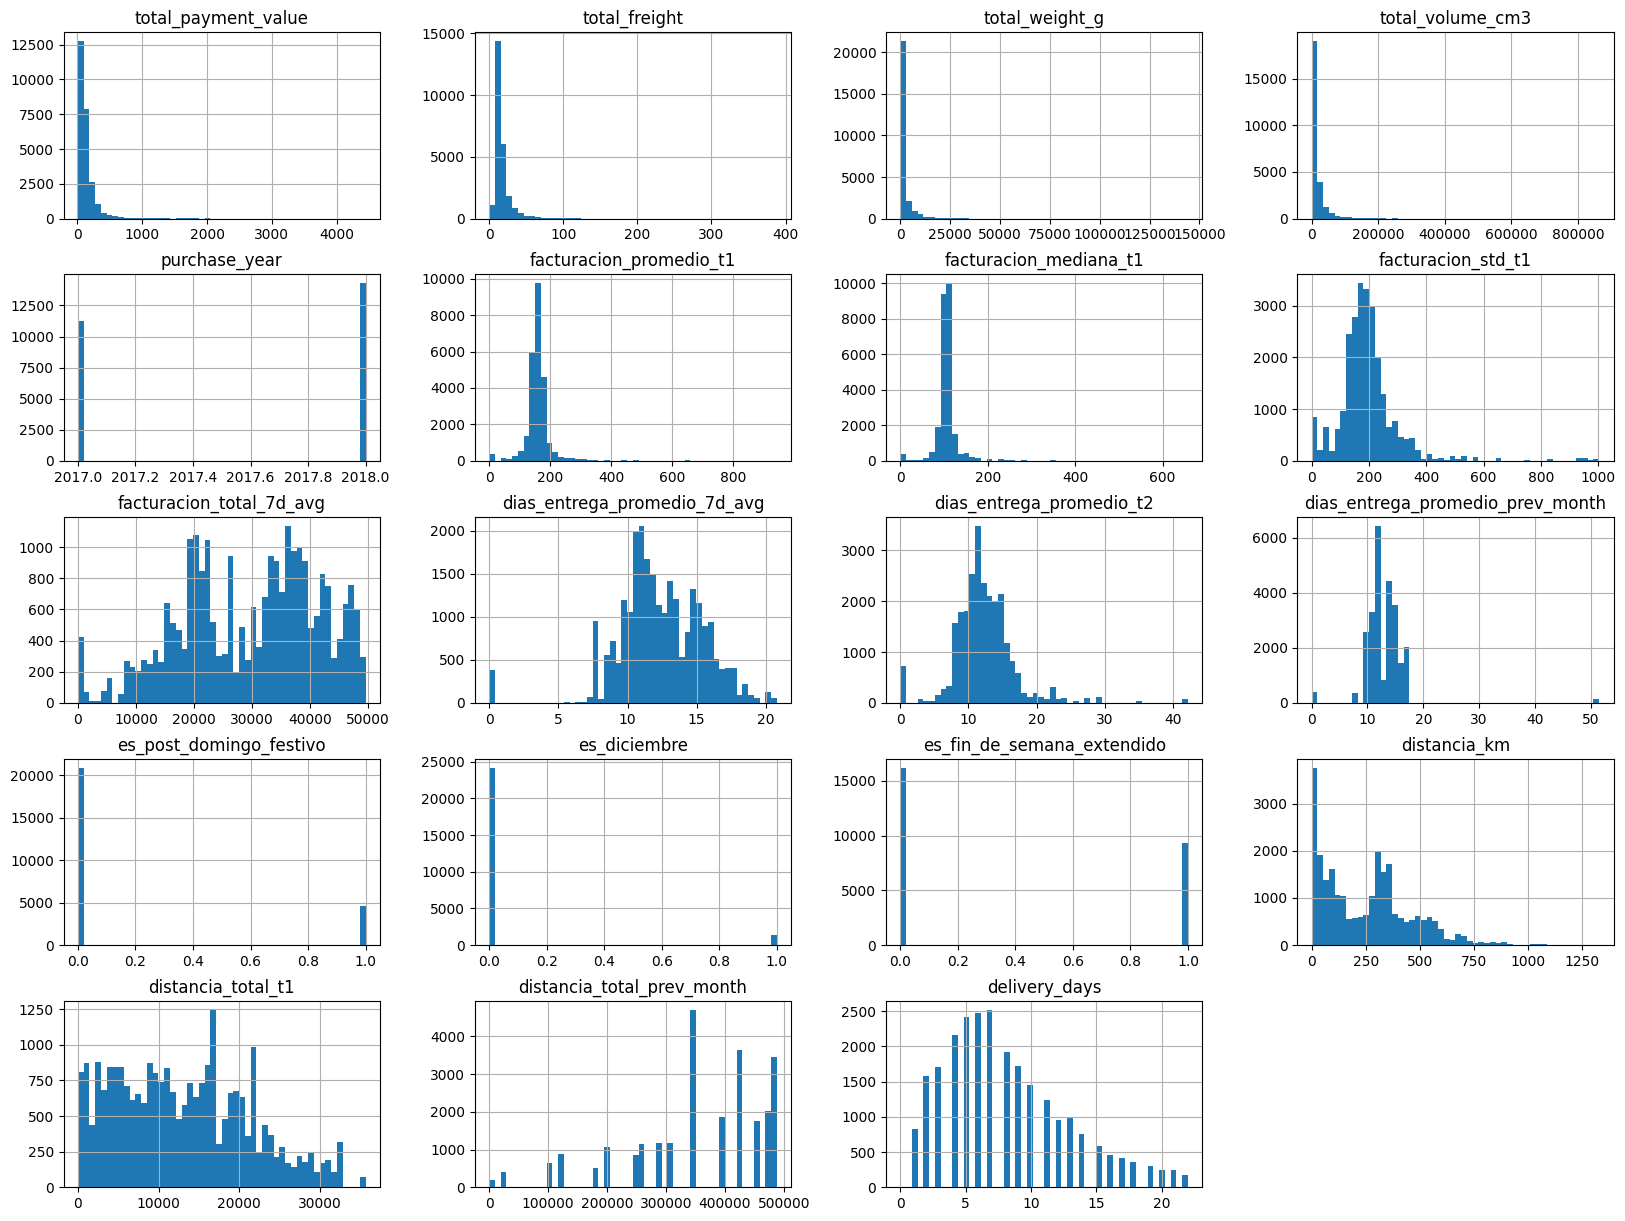

In [79]:
df.hist(bins=50, figsize=(20,15))

In [80]:
umbral = df["total_volume_cm3"].quantile(0.95)
df = df[df["total_volume_cm3"] <= umbral].reset_index(drop=True)


umbral = df["total_weight_g"].quantile(0.95)
df = df[df["total_weight_g"] <= umbral].reset_index(drop=True)


umbral = df["total_freight"].quantile(0.95)
df = df[df["total_freight"] <= umbral].reset_index(drop=True)
print((df["total_freight"] == 0).sum())   # cuántos registros tienen flete 0

df = df[df["total_freight"] != 0].reset_index(drop=True)

print(df.shape)

123
(21757, 22)


<Axes: >

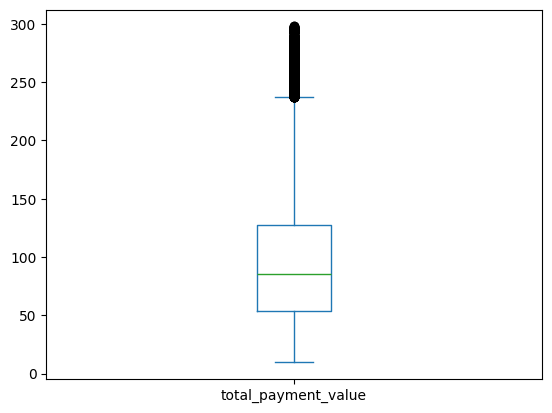

In [81]:
umbral = df["total_payment_value"].quantile(0.95)
df = df[df["total_payment_value"] <= umbral].reset_index(drop=True)

df["total_payment_value"].plot(kind='box')


<Axes: >

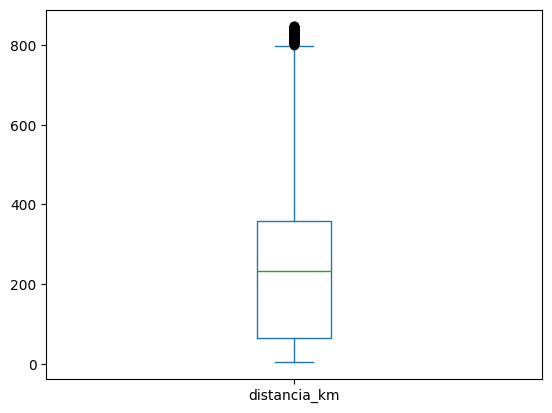

In [82]:
# df = df[df["facturacion_promedio_t1"] != 0].reset_index(drop=True)

umbral = df["distancia_km"].quantile(0.99)
df = df[df["distancia_km"] <= umbral].reset_index(drop=True)

df = df[df["distancia_km"] > 4].reset_index(drop=True)


df["distancia_km"].plot(kind='box')


In [83]:
df.shape

(20278, 22)

In [84]:
# Estadísticas de distancia_km por par (estado del cliente, estado del vendedor)
dist_estados = (
    df.groupby(["customer_state", "principal_seller_state_by_price"], observed=True)["distancia_km"]
      .agg(pedidos="count", minimo="min", maximo="max", promedio="mean", mediana="median")
      .round(1)
      .reset_index()
)
print(dist_estados)

# Estadísticas globales
print(df["distancia_km"].agg(["min", "max", "mean", "median"]).round(1))

  customer_state principal_seller_state_by_price  pedidos  minimo  maximo  \
0          b'RJ'                           b'MG'      333   131.8   797.7   
1          b'RJ'                           b'PR'      148   249.5   844.8   
2          b'RJ'                           b'RJ'      435     4.0   250.3   
3          b'RJ'                           b'SP'     2753    88.9   846.4   
4          b'SP'                           b'MG'      861    40.2   846.3   
5          b'SP'                           b'PR'     1370   129.8   841.3   
6          b'SP'                           b'RJ'      578   138.5   843.4   
7          b'SP'                           b'SP'    13800     4.0   729.3   

   promedio  mediana  
0     385.3    344.5  
1     705.2    684.2  
2      54.5     34.7  
3     447.1    406.3  
4     443.2    477.4  
5     474.3    480.8  
6     396.1    367.0  
7     156.5    112.4  
min         4.0
max       846.4
mean      242.0
median    233.2
Name: distancia_km, dtype: float64


<Axes: >

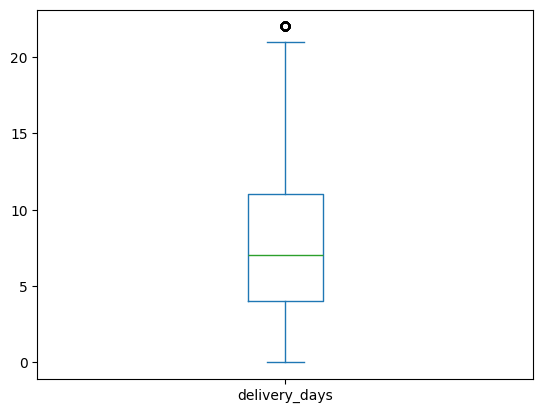

In [85]:
df["delivery_days"].plot(kind='box')

In [86]:
import pandas as pd

# 1. Eliminar los registros donde delivery_days es 0
df = df[df['delivery_days'] != 0].copy()

# 2. Definir los límites de los rangos (bins) y sus etiquetas
# Los bins funcionan de la forma (límite_inferior, límite_superior]
# Al usar 0 como inicio, el primer rango capturará desde el 1 hasta el 4.
bins = [0, 4, 7, 11, 22]
labels = ['0-4 días', '5-7 días', '8-11 días', '12-22 días']

# 3. Crear la nueva columna con la categoría
df['delivery_category'] = pd.cut(df['delivery_days'], bins=bins, labels=labels)

# 4. Verificar cómo quedaron distribuidas las categorías
print(df['delivery_category'].value_counts())

delivery_category
5-7 días      5990
0-4 días      5182
8-11 días     4962
12-22 días    4138
Name: count, dtype: int64


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20272 entries, 0 to 20277
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   customer_state                    20272 non-null  category
 1   total_payment_value               20272 non-null  float64 
 2   total_freight                     20272 non-null  float64 
 3   total_weight_g                    20272 non-null  float64 
 4   total_volume_cm3                  20272 non-null  float64 
 5   principal_category_by_price       20272 non-null  category
 6   principal_seller_state_by_price   20272 non-null  category
 7   purchase_year                     20272 non-null  float64 
 8   facturacion_promedio_t1           20272 non-null  float64 
 9   facturacion_mediana_t1            20272 non-null  float64 
 10  facturacion_std_t1                20272 non-null  float64 
 11  facturacion_total_7d_avg          20272 non-null  float64 


In [88]:
df.columns

Index(['customer_state', 'total_payment_value', 'total_freight',
       'total_weight_g', 'total_volume_cm3', 'principal_category_by_price',
       'principal_seller_state_by_price', 'purchase_year',
       'facturacion_promedio_t1', 'facturacion_mediana_t1',
       'facturacion_std_t1', 'facturacion_total_7d_avg',
       'dias_entrega_promedio_7d_avg', 'dias_entrega_promedio_t2',
       'dias_entrega_promedio_prev_month', 'es_post_domingo_festivo',
       'es_diciembre', 'es_fin_de_semana_extendido', 'distancia_km',
       'distancia_total_t1', 'distancia_total_prev_month', 'delivery_days',
       'delivery_category'],
      dtype='object')

In [89]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

# 1. Eliminar delivery_days
df = df.drop(columns=['delivery_days'])

# 2. Seleccionar columnas numéricas
num_cols = df.select_dtypes(include='number').columns.tolist()

# 3. Excluir binarias y el año
excluir = ['es_post_domingo_festivo', 'es_diciembre',
           'es_fin_de_semana_extendido', 'purchase_year']
num_cols = [c for c in num_cols if c not in excluir]

# 4. Normalizar entre 0 y 1
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df["purchase_year"] = df["purchase_year"].astype(int)
flags = ["es_post_domingo_festivo", "es_diciembre", "es_fin_de_semana_extendido"]
df[flags] = df[flags].astype(int)

cat_cols = ["customer_state", "principal_category_by_price", "principal_seller_state_by_price"]
for col in cat_cols:
    df[col] = (
        df[col].astype(object)
        .map(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)
        .astype("category")
    )

# 1. Separar la variable objetivo de las columnas categóricas a codificar con one-hot
target_col = 'delivery_category'
cat_cols_sin_target = [c for c in cat_cols if c != target_col]

# 2. Aplicar LabelEncoder SOLO a la variable objetivo
label_encoder = LabelEncoder()
df[target_col + '_encoded'] = label_encoder.fit_transform(df[target_col])

# Verificar el mapeo de categorías a números (importante para interpretar resultados después)
print("Mapeo de categorías:")
for i, clase in enumerate(label_encoder.classes_):
    print(f"{i} -> {clase}")

# 3. Aplicar one-hot encoding a las DEMÁS categóricas (sin incluir el target)
data = pd.get_dummies(df, columns=cat_cols_sin_target, drop_first=False, dtype=int)

# 4. Eliminar la columna original de texto del target (ya tenemos la versión encoded)
data = data.drop(columns=[target_col])

print(data.shape)
print([c for c in data.columns if "b'" in c])  # debe imprimir []
print(data.head())

Mapeo de categorías:
0 -> 0-4 días
1 -> 12-22 días
2 -> 5-7 días
3 -> 8-11 días
(20272, 33)
[]
   total_payment_value  total_freight  total_weight_g  total_volume_cm3  \
0             0.101101       0.118531        0.089286          0.029484   
1             0.080235       0.288815        0.035714          0.040087   
2             0.155435       0.426962        0.104107          0.146115   
3             0.069993       0.249165        0.044643          0.080755   
4             0.379370       0.128548        0.093750          0.072912   

   purchase_year  facturacion_promedio_t1  facturacion_mediana_t1  \
0           2017                 0.118482                0.139237   
1           2018                 0.179063                0.171168   
2           2018                 0.155291                0.152256   
3           2017                 0.180988                0.178642   
4           2017                 0.232419                0.162244   

   facturacion_std_t1  facturacion_tota

In [93]:
data["delivery_category_encoded"].value_counts()

delivery_category_encoded
2    5990
0    5182
3    4962
1    4138
Name: count, dtype: int64

In [94]:
#Validación Cruzada
from sklearn.model_selection import cross_validate, StratifiedKFold

#Dataframe para comparar los modelos
comparacion_CV=pd.DataFrame()
scoring=('f1_macro', 'accuracy','precision_macro', 'recall_macro')
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) #Muestreo estratificado

In [97]:
objetivo = 'delivery_category_encoded'
#Se separa variables predictoras y objetivo
X = data.drop(objetivo, axis = 1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20272 entries, 0 to 20277
Data columns (total 32 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   total_payment_value                                 20272 non-null  float64
 1   total_freight                                       20272 non-null  float64
 2   total_weight_g                                      20272 non-null  float64
 3   total_volume_cm3                                    20272 non-null  float64
 4   purchase_year                                       20272 non-null  int64  
 5   facturacion_promedio_t1                             20272 non-null  float64
 6   facturacion_mediana_t1                              20272 non-null  float64
 7   facturacion_std_t1                                  20272 non-null  float64
 8   facturacion_total_7d_avg                            20272 non-null  float64
 9   

In [117]:
#Tree
from sklearn import tree
modelTree = tree.DecisionTreeClassifier(criterion='gini', min_samples_leaf=7, max_depth=100)

scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# scores

print(scores.mean())    


fit_time                 0.168172
score_time               0.008525
test_f1_macro            0.418056
train_f1_macro           0.691599
test_accuracy            0.420186
train_accuracy           0.694110
test_precision_macro     0.416880
train_precision_macro    0.692780
test_recall_macro        0.420523
train_recall_macro       0.692278
dtype: float64


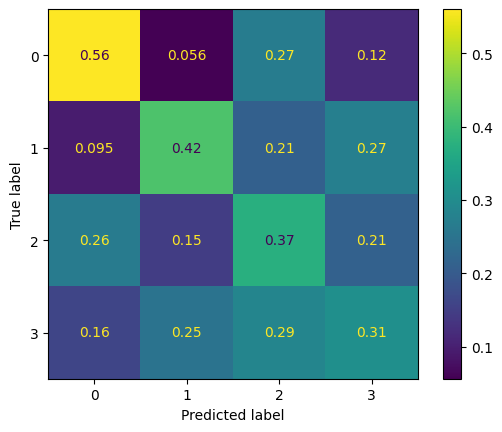

In [107]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = cross_val_predict(modelTree, X, Y, cv=10)
ConfusionMatrixDisplay(confusion_matrix(Y, y_pred, normalize='true')).plot()

In [104]:
print(Y.value_counts(normalize=True))

delivery_category_encoded
2    0.295481
0    0.255624
3    0.244771
1    0.204124
Name: proportion, dtype: float64


In [119]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=200,  max_samples=0.9, criterion='gini',
                              max_depth=20, min_samples_leaf=10, random_state=42, n_jobs=-1)

scores = cross_validate(model_rf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# scores

print(scores.mean())   

fit_time                 0.631925
score_time               0.068516
test_f1_macro            0.482368
train_f1_macro           0.674239
test_accuracy            0.490579
train_accuracy           0.677711
test_precision_macro     0.482905
train_precision_macro    0.681348
test_recall_macro        0.490144
train_recall_macro       0.674829
dtype: float64


In [126]:
#Método Perezoso
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=15, metric='euclidean')


scores = cross_validate(model_knn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# scores

print(scores.mean())   


fit_time                 0.009428
score_time               0.053972
test_f1_macro            0.423755
train_f1_macro           0.511123
test_accuracy            0.432271
train_accuracy           0.518307
test_precision_macro     0.424563
train_precision_macro    0.515058
test_recall_macro        0.431045
train_recall_macro       0.516875
dtype: float64


In [133]:
#Red neuronal

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: tanh, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios
from sklearn.neural_network import MLPClassifier

model_rn = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation='relu', solver='adam', learning_rate_init=0.001, alpha=1e-4, early_stopping=True, n_iter_no_change=20, max_iter=1000, random_state=3)

scores = cross_validate(model_rn, X, Y, cv=cv, scoring=scoring,
                        return_train_score=True, n_jobs=-1)
scores = pd.DataFrame(scores)
print(scores.agg(['mean', 'std']).T.round(4))



                         mean     std
fit_time               9.4423  2.3184
score_time             0.0168  0.0060
test_f1_macro          0.3461  0.0652
train_f1_macro         0.3475  0.0580
test_accuracy          0.3961  0.0327
train_accuracy         0.3978  0.0228
test_precision_macro   0.3688  0.0903
train_precision_macro  0.3760  0.0676
test_recall_macro      0.3841  0.0424
train_recall_macro     0.3857  0.0359


In [ ]:
#SVM
from sklearn.svm import SVC # SVR
model_svm=SVC(kernel='rbf', C=5)

scores = cross_validate(model_svm, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

# scores

print(scores.mean())   

c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p